# 04 - Centrality Analysis

In this notebook we calculate several different meanings of station importance: degree for local branching, weighted degree for scheduled service volume, weighted PageRank for importance in directed service flow, betweenness for shortest-path bridging, and harmonic centrality for accessibility. We then compare their rankings instead of assuming that a busy station and a structural bottleneck are the same thing.

**Question for this notebook:** *Do the inexpensive local or flow-based measures identify the same stops as global shortest-path measures? If not, which stations look ordinary by traffic or degree but important as bridges?*

**Input**
- `outputs/nb/02_graph_construction/` - the node table and the directed edge table produced by the `02_graph_construction` notebook (station attributes; `from_stop`, `to_stop`, trip frequency per segment).
- We do not need raw GTFS data for the main analysis. The final identity check uses `stop_times.txt` only if the file is already available; it never downloads 816 MB just for that check.

**Output** (all under `outputs/nb/04_centrality_analysis/`)
- `tables/stop_metrics.csv` - one row per station with all the centrality measures.
- `tables/top_degree.csv`, `top_weighted_degree.csv`, `top_pagerank.csv`, `top_approx_betweenness.csv`, `top_approx_harmonic.csv` - top-N rankings.
- `tables/centrality_correlation_spearman.csv` - Spearman matrix between the measures.
- `tables/betweenness_stability.csv` - how much the betweenness ranking changes when only the random sample of source nodes changes.
- `figures/` - top-N bar charts for each measure, a heatmap of the correlations, scatter plots of degree against the other measures, a map of the top betweenness stations, and the seed-vs-seed stability scatter plot.

The main precision limitation is betweenness. We approximate it from `K_BETWEENNESS = 300` sampled sources out of about 30,000 nodes, so the estimate uses roughly 1% of possible sources. We run a second seed and measure top-rank and threshold agreement because any cutoff based on this column inherits its sampling variation.

## 1. Environment setup

We begin with the shared environment helper. It searches upward for the GTFS directory, or clones the project into `/content` for a fresh Colab session, then changes to the repository root and defines `REPO`, `DATA`, and `OUT`. `_ensure(...)` installs only imports that are missing. All later file paths depend on these values.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Imports, output folders, and tunable constants

This cell imports the analysis libraries, creates this stage's `tables` and `figures` folders, and collects the settings that affect runtime or output size:

- `K_BETWEENNESS = 300` is the number of sources for approximate betweenness. Exact unweighted betweenness would require a shortest-path traversal from every node and take much longer; 300 sources usually takes a few minutes.
- `RUN_STABILITY_CHECK` repeats that estimate with a second seed. It roughly doubles the betweenness time but lets us measure sampling stability.
- `HARMONIC_SAMPLES = 300` sets the number of sampled sources for harmonic centrality. `None` requests the exact, much slower calculation.
- `TOP_N = 15` controls the displayed and saved short rankings.

The random seeds make repeated runs with the same settings comparable. All files from this notebook stay under `outputs/nb/04_centrality_analysis`.

In [2]:
_ensure("networkx", "pandas", "numpy", "matplotlib", "scipy")

import csv
import json
import pickle
import random
import time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

# ---------------- tunable constants (runtime lives here) ----------------
K_BETWEENNESS = 300          # sampled sources for approximate betweenness
BETWEENNESS_SEED = 42        # seed of the main sample
BETWEENNESS_SEED_B = 7       # seed of the second sample (noise check only)
RUN_STABILITY_CHECK = True   # False -> skip the second betweenness run
HARMONIC_SAMPLES = 300       # None -> exact harmonic centrality (very slow)
TOP_N = 15                   # rows per ranking table / bars per chart
CRITICAL_QUANTILE = 0.90     # p90 rule stress-tested in section 11

# ---------------- stage folders ----------------
STAGE = OUT / "04_centrality_analysis"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
STAGE02 = OUT / "02_graph_construction"

print("stage folder :", STAGE)
print("reads stage  :", STAGE02)
print("networkx", nx.__version__, "| pandas", pd.__version__)

stage folder : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis
reads stage  : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction
networkx 3.6.1 | pandas 3.0.5


## 3. Hebrew labels in matplotlib

Several charts use Hebrew station names. In this Matplotlib build, passing raw logical-order Hebrew produces the correct display, so we keep `fix_he()` as a no-op and choose fonts with Hebrew glyph coverage. The cell removes an old `Text.set_text` patch if one remains in the kernel, because applying bidi conversion before this renderer would reverse the text twice. It also disables scientific-offset labels.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove a bidi patch if the current kernel contains one, so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Loading the graph produced in notebook 02

We load notebook 02's node and directed-edge tables and reconstruct the two NetworkX objects needed for centrality:

- `D` keeps segment direction and scheduled frequency, so we use it for PageRank and directed in/out measures.
- `G` combines both directions and sums their weights, so we use it for neighbor counts, connectivity, betweenness, and harmonic distance.

`find_artifact()` locates the CSVs recursively, while `_pick()` recognizes the supported endpoint and weight column names. We still stop with an explicit error if the stage or a required column is missing. Edge weights are converted to numeric values, node attributes are attached from the node table, and opposite directed weights are accumulated in `G`.

In [4]:
def _find_artifact(stage_dir, names, keyword):
    """Locate a stage artifact by exact name, then by keyword, under <stage>/tables or <stage>."""
    for name in names:
        for cand in (stage_dir / "tables" / name, stage_dir / name):
            if cand.exists():
                return cand
    hits = sorted(p for p in stage_dir.rglob("*.csv") if keyword in p.name.lower())
    return hits[0] if hits else None


def _pick_column(df, candidates):
    """Return the first column of df matching one of candidates (case-insensitive)."""
    lower = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand in lower:
            return lower[cand]
    return None


if not STAGE02.exists():
    raise FileNotFoundError(
        f"{STAGE02} missing - run notebook 02_graph_construction first."
    )

edges_path = _find_artifact(
    STAGE02,
    ["edges.csv", "graph_edges.csv", "edges_directed.csv", "directed_edges.csv"],
    "edge",
)
nodes_path = _find_artifact(
    STAGE02, ["nodes.csv", "graph_nodes.csv", "stops_nodes.csv"], "node"
)
if edges_path is None:
    raise FileNotFoundError(
        f"No edge table found under {STAGE02} - run notebook 02_graph_construction first."
    )
print("edges from:", edges_path)
print("nodes from:", nodes_path)

edges_df = pd.read_csv(edges_path, dtype=str, encoding="utf-8-sig")
src_col = _pick_column(edges_df, ["from_stop", "from_stop_id", "source", "from", "u"])
dst_col = _pick_column(edges_df, ["to_stop", "to_stop_id", "target", "to", "v"])
wgt_col = _pick_column(
    edges_df, ["trip_frequency", "weight", "frequency", "trips", "n_trips", "count"]
)
if src_col is None or dst_col is None:
    raise ValueError(f"Cannot identify endpoint columns in {edges_path}: {list(edges_df.columns)}")
weights = (
    pd.to_numeric(edges_df[wgt_col], errors="coerce").fillna(1.0)
    if wgt_col is not None
    else pd.Series(1.0, index=edges_df.index)
)

# Directed trip graph: weight = number of trips using the segment.
D = nx.DiGraph()
for u, v, w in zip(edges_df[src_col], edges_df[dst_col], weights):
    if u == v or pd.isna(u) or pd.isna(v):
        continue
    if D.has_edge(u, v):
        D[u][v]["weight"] += float(w)
    else:
        D.add_edge(u, v, weight=float(w))

# Undirected projection: weight = sum of both directions.
G = nx.Graph()
for u, v, data in D.edges(data=True):
    if G.has_edge(u, v):
        G[u][v]["weight"] += data["weight"]
    else:
        G.add_edge(u, v, weight=data["weight"])

# Station attributes (name, coordinates, region, metro) if notebook 02 saved them.
ATTR = {}
VISIT_COL = None
if nodes_path is not None:
    nodes_df = pd.read_csv(nodes_path, dtype=str, encoding="utf-8-sig")
    id_col = _pick_column(nodes_df, ["stop_id", "node", "id"])
    name_col = _pick_column(nodes_df, ["stop_name", "name"])
    lat_col = _pick_column(nodes_df, ["lat", "stop_lat", "latitude"])
    lon_col = _pick_column(nodes_df, ["lon", "stop_lon", "longitude"])
    reg_col = _pick_column(nodes_df, ["region", "district"])
    met_col = _pick_column(nodes_df, ["metro", "metropolitan"])
    VISIT_COL = _pick_column(
        nodes_df,
        ["stop_use_count", "visits", "stop_visits", "visit_count", "n_visits"],
    )
    if id_col is not None:
        for row in nodes_df.itertuples(index=False):
            rec = dict(zip(nodes_df.columns, row))
            sid = rec[id_col]
            ATTR[sid] = {
                "stop_name": rec.get(name_col, "") if name_col else "",
                "lat": pd.to_numeric(rec.get(lat_col), errors="coerce") if lat_col else np.nan,
                "lon": pd.to_numeric(rec.get(lon_col), errors="coerce") if lon_col else np.nan,
                "region": rec.get(reg_col, "") if reg_col else "",
                "metro": rec.get(met_col, "") if met_col else "",
                "stop_use_count": pd.to_numeric(rec.get(VISIT_COL), errors="coerce")
                if VISIT_COL
                else np.nan,
            }
        # Keep stations that stage 02 listed even if they ended up with no segment.
        G.add_nodes_from(ATTR.keys())
        D.add_nodes_from(ATTR.keys())

print(f"directed graph  : {D.number_of_nodes():,} nodes, {D.number_of_edges():,} edges")
print(f"undirected graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"attributes for  : {len(ATTR):,} stations"
      + (f" (visit counts in column '{VISIT_COL}')" if VISIT_COL else " (no visit-count column)"))

edges from: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv
nodes from: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv
directed graph  : 30,463 nodes, 51,999 edges
undirected graph: 30,463 nodes, 51,772 edges
attributes for  : 30,463 stations (visit counts in column 'stop_use_count')


## 5. Sanity check and the largest connected component

We identify the largest connected component of `G` before running the expensive global measures. Betweenness and harmonic centrality are calculated on this subgraph so their path sets refer to the main connected network. We later assign zero to nodes outside it and keep an `in_largest_component` flag so those structural zeros can be distinguished. The printed LCC size and share show how much of the graph these calculations cover.

In [5]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
Gc = G.subgraph(components[0]).copy()

n_nodes = G.number_of_nodes()
print(f"connected components : {len(components):,}")
print(f"largest component    : {Gc.number_of_nodes():,} nodes "
      f"({Gc.number_of_nodes() / n_nodes:.1%} of the network), "
      f"{Gc.number_of_edges():,} edges")
print(f"isolated / off-LCC   : {n_nodes - Gc.number_of_nodes():,} stations")
print(f"average degree       : {2 * G.number_of_edges() / n_nodes:.2f}")
print(f"betweenness sampling : k = {min(K_BETWEENNESS, Gc.number_of_nodes()):,} sources "
      f"= {min(K_BETWEENNESS, Gc.number_of_nodes()) / Gc.number_of_nodes():.2%} of the LCC")

connected components : 12
largest component    : 30,237 nodes (99.3% of the network), 51,523 edges
isolated / off-LCC   : 226 stations
average degree       : 3.40
betweenness sampling : k = 300 sources = 0.99% of the LCC


## 6. Degree and weighted degree

We start with measures that come directly from node and edge dictionaries and therefore cost almost nothing:

- `degree` counts distinct undirected neighboring stops, so it measures local branching.
- `degree_centrality` divides degree by `n - 1`, which puts it on NetworkX's normalized scale without changing the ranking.
- `weighted_degree` sums the undirected edge frequencies, so a stop on a small number of very frequent connections can rank highly even without many distinct neighbors.
- `in_degree`, `out_degree`, `in_weight`, and `out_weight` preserve direction. Large differences can point to terminals, loops, or asymmetric scheduled service.

The cell builds one dataframe keyed by `stop_id`, attaches the station attributes, and prints the top degree and weighted-degree rows for an immediate comparison.

In [6]:
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
in_degree = dict(D.in_degree())
out_degree = dict(D.out_degree())
in_weight = dict(D.in_degree(weight="weight"))
out_weight = dict(D.out_degree(weight="weight"))

print("degree      : max", max(degree.values()), "| mean", round(np.mean(list(degree.values())), 2))
print("weighted deg: max", int(max(weighted_degree.values())),
      "| mean", round(np.mean(list(weighted_degree.values())), 1))

degree      : max 62 | mean 3.4
weighted deg: max 21396 | mean 1003.9


## 7. Weighted PageRank on the directed graph

Weighted PageRank gives a station more score when high-scoring stations point to it through frequently scheduled directed segments. We use `alpha = 0.85`, so the random-walk interpretation follows outgoing service 85% of the time and teleports to a random node 15% of the time. This makes PageRank a recursive flow score rather than a simple neighbor count.

We run it on directed graph `D` with `weight="weight"`, preserving one-way and asymmetric service. Rank from dangling nodes with no outgoing edge is redistributed according to the standard PageRank treatment.

The cell first tries NetworkX's normal solver. If that path is unavailable, `_pagerank_python()` performs the same iterative update and checks convergence against `tol`. We store the result in the metrics table and print its sum, which should be approximately 1, along with the highest-ranked stations.

In [7]:
def weighted_pagerank(graph, weight="weight", alpha=0.85, max_iter=100, tol=1.0e-6):
    """Weighted PageRank via power iteration, without requiring SciPy."""
    nodes = list(graph.nodes)
    n = len(nodes)
    if n == 0:
        return {}
    rank = {node: 1.0 / n for node in nodes}
    out_w = {
        node: sum(data.get(weight, 1.0) for _, _, data in graph.out_edges(node, data=True))
        for node in nodes
    }
    for _ in range(max_iter):
        previous = rank
        dangling = sum(previous[node] for node in nodes if out_w[node] == 0)
        base = (1.0 - alpha) / n + alpha * dangling / n
        rank = {node: base for node in nodes}
        for source in nodes:
            total = out_w[source]
            if total == 0:
                continue
            src_rank = previous[source]
            for _, target, data in graph.out_edges(source, data=True):
                rank[target] += alpha * src_rank * data.get(weight, 1.0) / total
        if sum(abs(rank[node] - previous[node]) for node in nodes) < n * tol:
            return rank
    return rank


t0 = time.time()
try:
    pagerank = nx.pagerank(D, alpha=0.85, weight="weight")
    engine = "networkx (SciPy)"
except Exception as exc:  # SciPy missing or convergence failure
    print("networkx pagerank unavailable ->", exc, "| falling back to pure Python")
    pagerank = weighted_pagerank(D, weight="weight")
    engine = "pure Python power iteration"

print(f"PageRank via {engine} in {time.time() - t0:.1f}s; "
      f"sum = {sum(pagerank.values()):.4f} (should be ~1.0)")

PageRank via networkx (SciPy) in 0.2s; sum = 1.0000 (should be ~1.0)


## 8. Approximate betweenness centrality

Betweenness measures the share of shortest paths that pass through a node. A stop with only two neighbors can still score highly if those neighbors connect large parts of the graph, so this is the main measure here that can reveal bridging missed by local service volume.

Exact unweighted Brandes would run a breadth-first traversal from every node in the LCC. We instead call NetworkX's approximation with `k = min(K_BETWEENNESS, |LCC|)`, a fixed seed, normalization, and no edge weights. Here "shortest" therefore means fewest scheduled segments, not minimum time, distance, or inverse frequency.

With 300 sources this is still a noisy estimate. We insert zeros for nodes outside the LCC, time the calculation, and print the top scores, but we do not treat small rank differences as exact. The second-seed comparison below will show how stable the selected stations actually are.

In [8]:
k_eff = min(K_BETWEENNESS, Gc.number_of_nodes())
print(f"Computing sampled betweenness with {k_eff} pivots; expect roughly 30 seconds ...", flush=True)
t0 = time.time()
betweenness = nx.betweenness_centrality(
    Gc, k=k_eff, seed=BETWEENNESS_SEED, normalized=True, weight=None
)
print(f"approximate betweenness: k={k_eff}, seed={BETWEENNESS_SEED}, "
      f"{time.time() - t0:.1f}s")
nonzero = sum(1 for v in betweenness.values() if v > 0)
print(f"stations with a non-zero estimate: {nonzero:,} of {len(betweenness):,} "
      f"({nonzero / len(betweenness):.1%}) - the rest were simply never on a sampled path")

Computing sampled betweenness with 300 pivots; expect roughly 30 seconds ...
approximate betweenness: k=300, seed=42, 12.1s
stations with a non-zero estimate: 27,552 of 30,237 (91.1%) - the rest were simply never on a sampled path


## 9. Harmonic centrality (sampled) on the largest connected component

Harmonic centrality sums $1/d(u,v)$ over other nodes, giving more credit for short paths and zero contribution for unreachable nodes. It measures how near a station is to the rest of the network, which is accessibility rather than the through-path role captured by betweenness.

The exact calculation also requires one breadth-first search per source. With a finite `HARMONIC_SAMPLES`, we draw reproducible sources, accumulate reciprocal unweighted distances for every reached destination, and rescale by `|LCC| / samples`. Distance symmetry in this undirected graph makes source sampling an estimator of each destination's full sum. Setting the parameter to `None` uses NetworkX's exact calculation. We assign zero outside the LCC, record which method ran, and print the top stations.

In [9]:
def approximate_harmonic_centrality(graph, samples, seed):
    """Estimate harmonic centrality from `samples` random BFS sources, rescaled to n."""
    if graph.number_of_nodes() == 0 or not samples:
        return {}
    rng = random.Random(seed)
    nodes = list(graph.nodes)
    sources = rng.sample(nodes, min(samples, len(nodes)))
    scores = defaultdict(float)
    for source in sources:
        lengths = nx.single_source_shortest_path_length(graph, source)
        for target, distance in lengths.items():
            if target == source or distance == 0:
                continue
            scores[target] += 1.0 / distance
    scale = graph.number_of_nodes() / len(sources)
    return {node: value * scale for node, value in scores.items()}


t0 = time.time()
if HARMONIC_SAMPLES is None:
    harmonic = nx.harmonic_centrality(Gc)
    harmonic_mode = "exact"
else:
    harmonic = approximate_harmonic_centrality(Gc, HARMONIC_SAMPLES, BETWEENNESS_SEED)
    harmonic_mode = f"sampled ({HARMONIC_SAMPLES} sources)"
print(f"harmonic centrality [{harmonic_mode}] in {time.time() - t0:.1f}s "
      f"for {len(harmonic):,} stations")

harmonic centrality [sampled (300 sources)] in 3.8s for 30,237 stations


## 10. Assembling `stop_metrics.csv` and the top-N tables

All metric dictionaries are keyed by `stop_id`, so we now assemble them into one row per graph node with name, coordinates, region, metro, and LCC membership. The zero values outside the LCC remain explicit rather than becoming missing data.

We save the complete `stop_metrics.csv` and a separate top-`TOP_N` table for degree, weighted degree, PageRank, approximate betweenness, and approximate harmonic centrality. Ties are made deterministic with `stop_id`, and the printed file list confirms the artifacts needed by the next notebooks.

In [10]:
default_attr = {"stop_name": "", "lat": np.nan, "lon": np.nan,
                "region": "", "metro": "", "stop_use_count": np.nan}

rows = []
for stop_id in G.nodes:
    a = ATTR.get(stop_id, default_attr)
    deg = degree.get(stop_id, 0)
    rows.append({
        "stop_id": stop_id,
        "stop_name": a.get("stop_name", ""),
        "region": a.get("region", ""),
        "metro": a.get("metro", ""),
        "lat": a.get("lat", np.nan),
        "lon": a.get("lon", np.nan),
        "stop_use_count": a.get("stop_use_count", np.nan),
        "degree": deg,
        "degree_centrality": deg / (n_nodes - 1) if n_nodes > 1 else 0.0,
        "weighted_degree": weighted_degree.get(stop_id, 0.0),
        "in_degree": in_degree.get(stop_id, 0),
        "out_degree": out_degree.get(stop_id, 0),
        "in_weight": in_weight.get(stop_id, 0.0),
        "out_weight": out_weight.get(stop_id, 0.0),
        "pagerank": pagerank.get(stop_id, 0.0),
        "approx_betweenness": betweenness.get(stop_id, 0.0),
        "approx_harmonic": harmonic.get(stop_id, 0.0),
        "in_largest_component": stop_id in Gc,
    })

metrics = pd.DataFrame(rows).sort_values("weighted_degree", ascending=False)
metrics["label"] = metrics["stop_name"].fillna("").astype(str).str.strip()
metrics["label"] = metrics["label"].where(metrics["label"] != "", metrics["stop_id"])

metrics.drop(columns=["label"]).to_csv(
    TABLES / "stop_metrics.csv", index=False, encoding="utf-8-sig"
)

RANKINGS = {
    "top_degree.csv": "degree",
    "top_weighted_degree.csv": "weighted_degree",
    "top_pagerank.csv": "pagerank",
    "top_approx_betweenness.csv": "approx_betweenness",
    "top_approx_harmonic.csv": "approx_harmonic",
}
for filename, column in RANKINGS.items():
    (metrics.drop(columns=["label"])
            .sort_values(column, ascending=False)
            .head(TOP_N)
            .to_csv(TABLES / filename, index=False, encoding="utf-8-sig"))

print(f"stop_metrics.csv written: {len(metrics):,} rows -> {TABLES}")
display(metrics.nlargest(10, "approx_betweenness")[
    ["stop_name", "stop_id", "region", "degree", "weighted_degree",
     "pagerank", "approx_betweenness"]
])

stop_metrics.csv written: 30,463 rows -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables


,stop_name,stop_id,region,degree,weighted_degree,pagerank,approx_betweenness
266,ת.התרעננות/דור אלון מגל 6,17303,Center,16,220.0,0.000010,0.112456
229,מחלף חמד,41133,Jerusalem,62,10454.0,0.000125,0.087533
1315,מחלף קמה לצפון,27689,South,24,1304.0,0.000092,0.071646
354,דרך האר''י/ כביש 375,7444,Jerusalem,29,5272.0,0.000056,0.069168
1792,מחלף חמד,41132,Jerusalem,44,10540.0,0.000399,0.066711
964,שדרות בית הלל/כניסה לעיר,7562,Center,29,3870.0,0.000082,0.065783
556,רבי יהודה הנשיא/כניסה לעיר,23418,Center,24,1374.0,0.000047,0.056597
5272,מחלף קסם,748,Center,19,1534.0,0.000059,0.047271
1305,תחנת התרעננות/פונדק בית קמה,29243,South,19,520.0,0.000027,0.046288
5918,צומת חנניה צומת שבע,18876,North,13,636.0,0.000034,0.043863


## 11. How stable is the sampled betweenness?

We rerun the same betweenness approximation with a second seed. The graph and `k` stay fixed; only the sampled source nodes change. We compare the two results in three ways:

1. Spearman correlation across all LCC scores checks whether the overall ordering is similar, although the large number of near-zero values can make this look more stable than the top ranks are.
2. Top-50 overlap checks whether the short list of highest-ranked stations survives a source-sample change.
3. A p90-set Jaccard score checks agreement when we turn a continuous estimate into a top-decile flag. This is especially important because thresholding can flip stations that lie close to the cutoff.

The cell saves both score columns and their absolute difference, prints the summary measures, and plots seed A against seed B on log-scaled axes. If `RUN_STABILITY_CHECK` is false, it records that the comparison was skipped rather than implying stability.

Running the second 300-pivot betweenness sample for the stability check ...
second betweenness run (seed=7) in 13.8s


,value
k_samples,300.000000
lcc_nodes,30237.000000
sampling_fraction,0.009922
spearman_all_nodes,0.956400
spearman_both_positive,0.941600
top10_overlap,0.900000
top50_overlap,0.840000
p90_flag_jaccard,0.529600
p90_flagged_seed_a,3024.000000
p90_flagged_seed_b,3024.000000


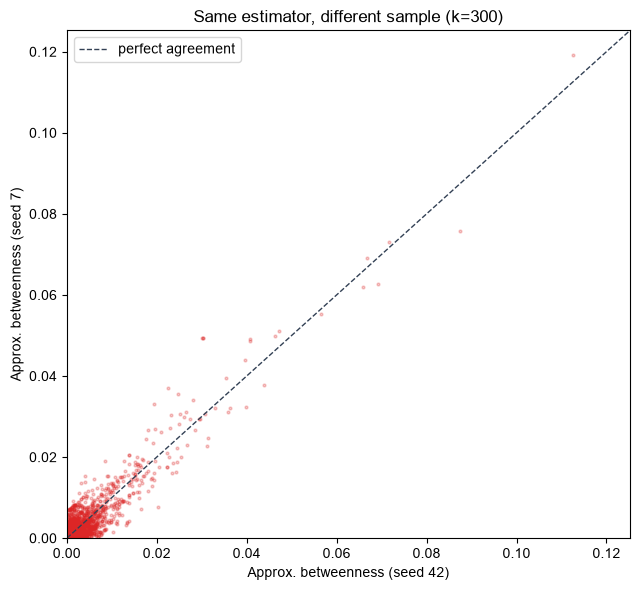

In [11]:
stability = None
if RUN_STABILITY_CHECK:
    print(f"Running the second {k_eff}-pivot betweenness sample for the stability check ...", flush=True)
    t0 = time.time()
    betweenness_b = nx.betweenness_centrality(
        Gc, k=k_eff, seed=BETWEENNESS_SEED_B, normalized=True, weight=None
    )
    print(f"second betweenness run (seed={BETWEENNESS_SEED_B}) in {time.time() - t0:.1f}s")

    joint = pd.DataFrame({
        "seed_a": pd.Series(betweenness),
        "seed_b": pd.Series(betweenness_b),
    }).fillna(0.0)

    rho_all = joint["seed_a"].corr(joint["seed_b"], method="spearman")
    both_positive = joint[(joint["seed_a"] > 0) & (joint["seed_b"] > 0)]
    rho_pos = both_positive["seed_a"].corr(both_positive["seed_b"], method="spearman")

    top_a = set(joint.nlargest(50, "seed_a").index)
    top_b = set(joint.nlargest(50, "seed_b").index)
    overlap50 = len(top_a & top_b) / 50
    top_a10 = set(joint.nlargest(10, "seed_a").index)
    top_b10 = set(joint.nlargest(10, "seed_b").index)
    overlap10 = len(top_a10 & top_b10) / 10

    thr_a = joint["seed_a"].quantile(CRITICAL_QUANTILE)
    thr_b = joint["seed_b"].quantile(CRITICAL_QUANTILE)
    flag_a = joint["seed_a"] > thr_a
    flag_b = joint["seed_b"] > thr_b
    union = int((flag_a | flag_b).sum())
    jaccard = int((flag_a & flag_b).sum()) / union if union else float("nan")

    stability = pd.DataFrame([{
        "k_samples": k_eff,
        "lcc_nodes": Gc.number_of_nodes(),
        "sampling_fraction": k_eff / Gc.number_of_nodes(),
        "spearman_all_nodes": round(float(rho_all), 4),
        "spearman_both_positive": round(float(rho_pos), 4),
        "top10_overlap": overlap10,
        "top50_overlap": overlap50,
        "p90_flag_jaccard": round(float(jaccard), 4),
        "p90_flagged_seed_a": int(flag_a.sum()),
        "p90_flagged_seed_b": int(flag_b.sum()),
    }])
    stability.to_csv(TABLES / "betweenness_stability.csv", index=False, encoding="utf-8-sig")
    display(stability.T.rename(columns={0: "value"}))

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(joint["seed_a"], joint["seed_b"], s=4, alpha=0.25, color="#dc2626")
    lim = max(joint["seed_a"].max(), joint["seed_b"].max()) * 1.05
    ax.plot([0, lim], [0, lim], color="#334155", lw=1, ls="--", label="perfect agreement")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel(f"Approx. betweenness (seed {BETWEENNESS_SEED})")
    ax.set_ylabel(f"Approx. betweenness (seed {BETWEENNESS_SEED_B})")
    ax.set_title(f"Same estimator, different sample (k={k_eff})")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_seed_stability.png", dpi=150)
    plt.show()
else:
    print("RUN_STABILITY_CHECK is False - skipping the betweenness noise measurement.")

## 12. Do the measures agree? The Spearman correlation matrix

We use Spearman rank correlation because the centrality distributions are skewed and we care about ordering rather than a linear relationship between raw score magnitudes. Pearson correlation would be dominated by a small number of extreme nodes.

We expect degree and weighted degree to agree partly because branching and service volume often concentrate at the same hubs. PageRank should also track weighted incoming service because frequency is part of its transition probabilities. The comparison we care most about is approximate betweenness against those local and flow measures: weaker agreement would show that bridging is not just another name for busyness. Sampling error in betweenness can reduce the observed correlations, so we interpret small differences cautiously. The cell saves the matrix and a labeled heatmap.

,degree,weighted_degree,pagerank,approx_betweenness,approx_harmonic
degree,1.0000,0.4681,0.4877,0.5139,0.4434
weighted_degree,0.4681,1.0000,0.6084,0.1868,0.3630
pagerank,0.4877,0.6084,1.0000,0.3220,0.0990
approx_betweenness,0.5139,0.1868,0.3220,1.0000,0.2772
approx_harmonic,0.4434,0.3630,0.0990,0.2772,1.0000


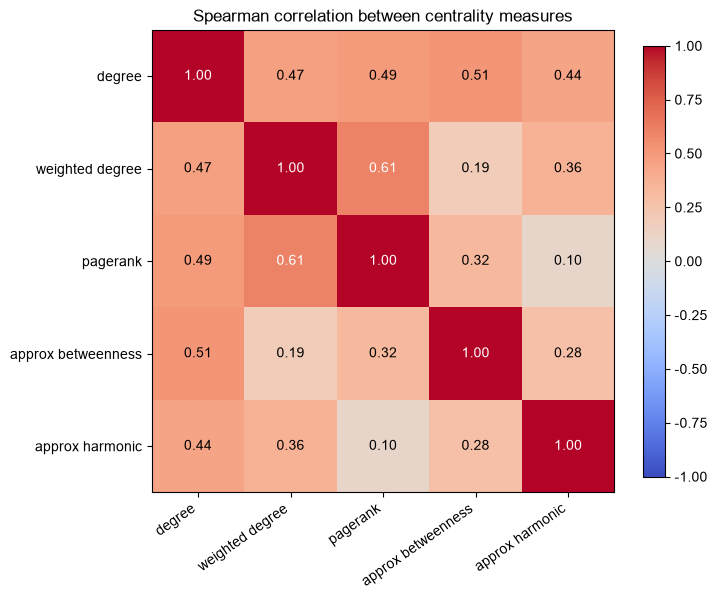

In [12]:
CORR_COLS = ["degree", "weighted_degree", "pagerank", "approx_betweenness", "approx_harmonic"]
corr = metrics[CORR_COLS].astype(float).corr(method="spearman").round(4)
corr.to_csv(TABLES / "centrality_correlation_spearman.csv", encoding="utf-8-sig")
display(corr)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(CORR_COLS)))
ax.set_xticklabels([c.replace("_", " ") for c in CORR_COLS], rotation=35, ha="right")
ax.set_yticks(range(len(CORR_COLS)))
ax.set_yticklabels([c.replace("_", " ") for c in CORR_COLS])
for i in range(len(CORR_COLS)):
    for j in range(len(CORR_COLS)):
        value = corr.values[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.6 else "black", fontsize=10)
ax.set_title("Spearman correlation between centrality measures")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "centrality_correlation_heatmap.png", dpi=150)
plt.show()

## 13. The top stations for each measure

We draw one horizontal top-`TOP_N` chart for each measure, using a station name when available and falling back to `stop_id`. The y-axis uses explicit numeric positions, so two different stops sharing the same Hebrew name remain separate bars rather than collapsing into one category.

The comparison is what matters: repeated names indicate agreement, while a stop that appears only in the betweenness list may be a low-volume connector. The plotting function uses plain-decimal formatting for small values and saves a separate PNG for every metric.

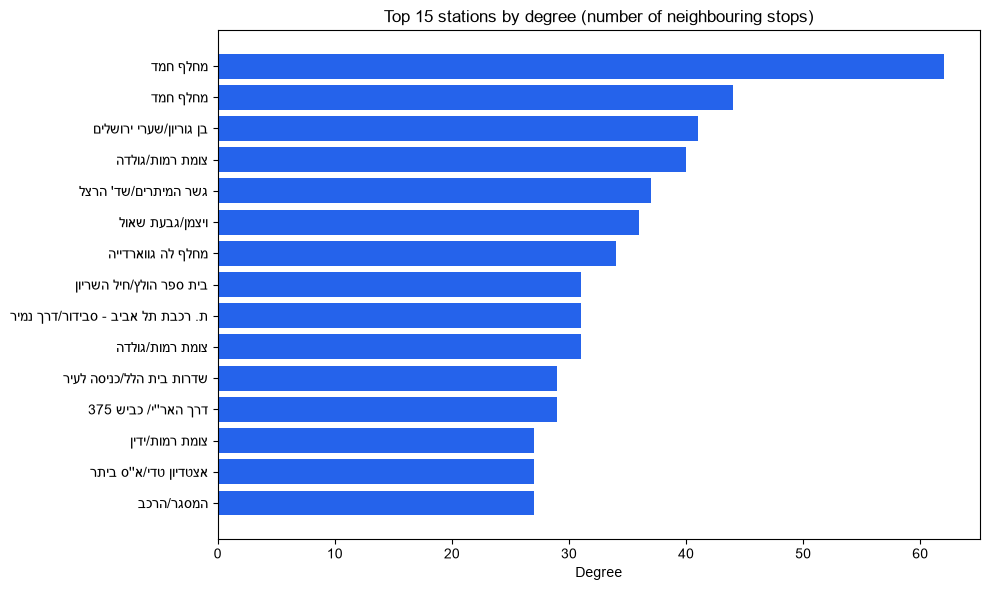

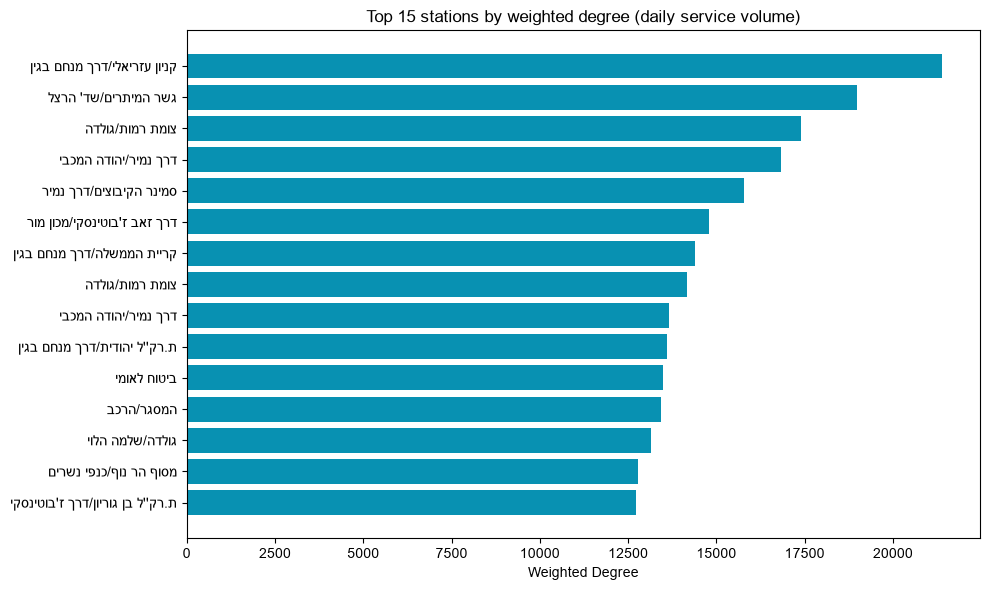

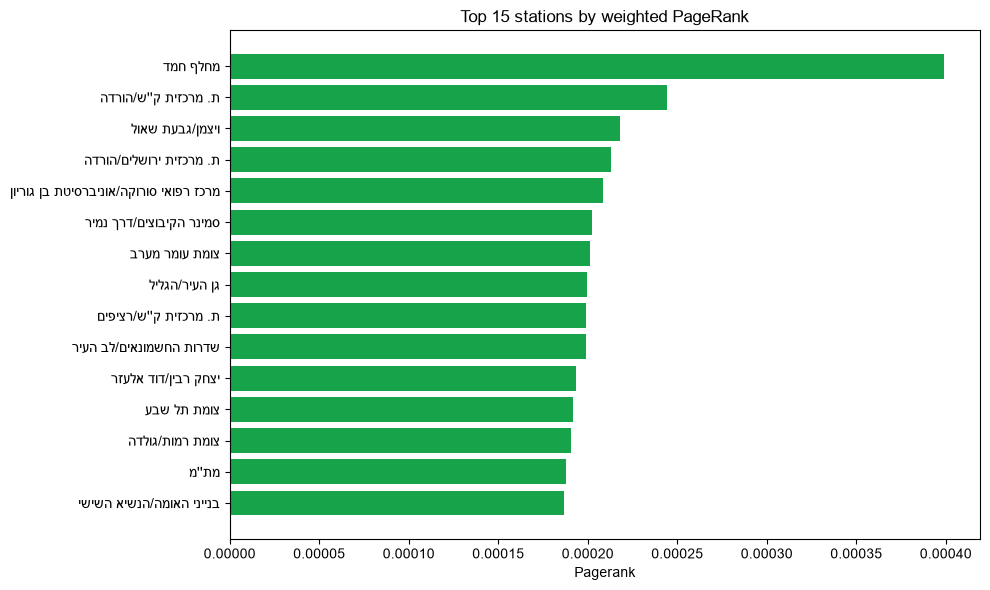

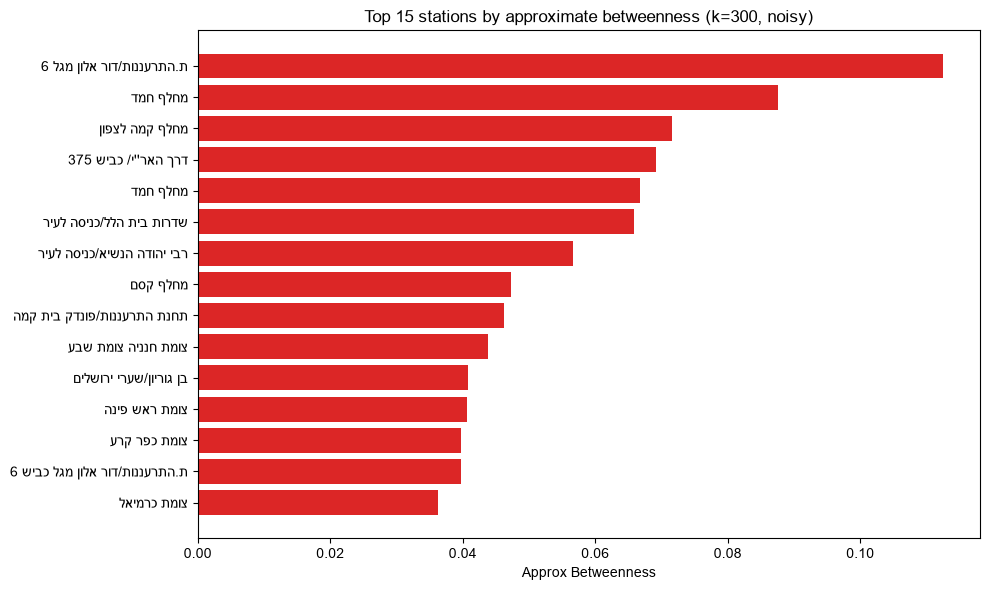

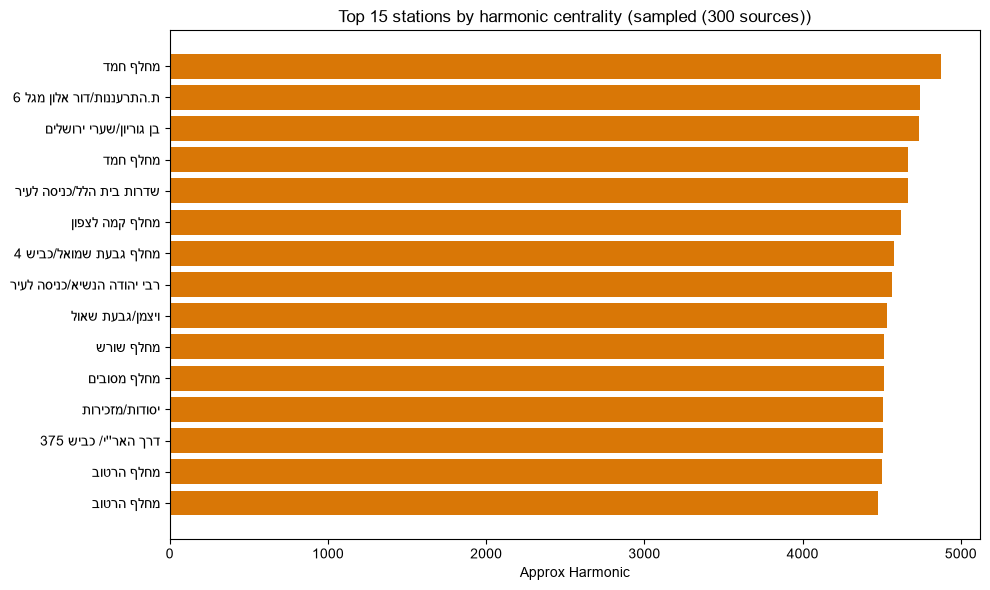

In [13]:
def plot_top(df, column, title, color, filename, n=TOP_N):
    top = df.nlargest(n, column)[["label", column]].copy().sort_values(column)
    y = np.arange(len(top))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(y, top[column].astype(float).values, color=color)
    ax.set_yticks(y)
    ax.set_yticklabels(top["label"].astype(str).values)
    ax.set_xlabel(column.replace("_", " ").title())
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIGURES / filename, dpi=150)
    plt.show()


plot_top(metrics, "degree",
         f"Top {TOP_N} stations by degree (number of neighbouring stops)",
         "#2563eb", "top_degree.png")
plot_top(metrics, "weighted_degree",
         f"Top {TOP_N} stations by weighted degree (daily service volume)",
         "#0891b2", "top_weighted_degree.png")
plot_top(metrics, "pagerank",
         f"Top {TOP_N} stations by weighted PageRank",
         "#16a34a", "top_pagerank.png")
plot_top(metrics, "approx_betweenness",
         f"Top {TOP_N} stations by approximate betweenness (k={k_eff}, noisy)",
         "#dc2626", "top_approx_betweenness.png")
plot_top(metrics, "approx_harmonic",
         f"Top {TOP_N} stations by harmonic centrality ({harmonic_mode})",
         "#d97706", "top_approx_harmonic.png")

## 14. Where the measures disagree: scatter plots and a map

The correlation matrix compresses each relationship to one coefficient, so we use scatter plots to see which nodes create disagreement.

- In degree versus betweenness, points with low degree and high betweenness are the connectors a local ranking misses.
- Degree versus PageRank should be tighter because both reward locally well-connected service, although direction and recursive weighting can still separate them.
- The map shows all finite-coordinate nodes faintly and highlights the top 50 betweenness values by size and color. Corridor concentration is a useful geographic check, but it cannot prove that the sampled scores are exact; the second-seed statistics remain the quantitative stability test.

We use logarithmic axes only where positive skewed values need them, save the scatter panel and map, and label the highest betweenness stations directly.

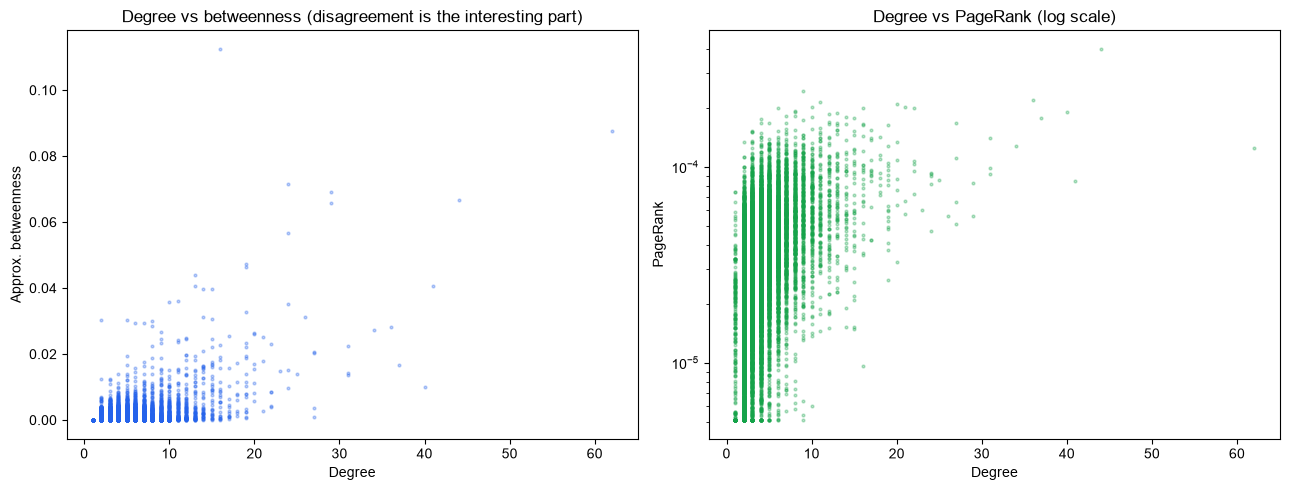

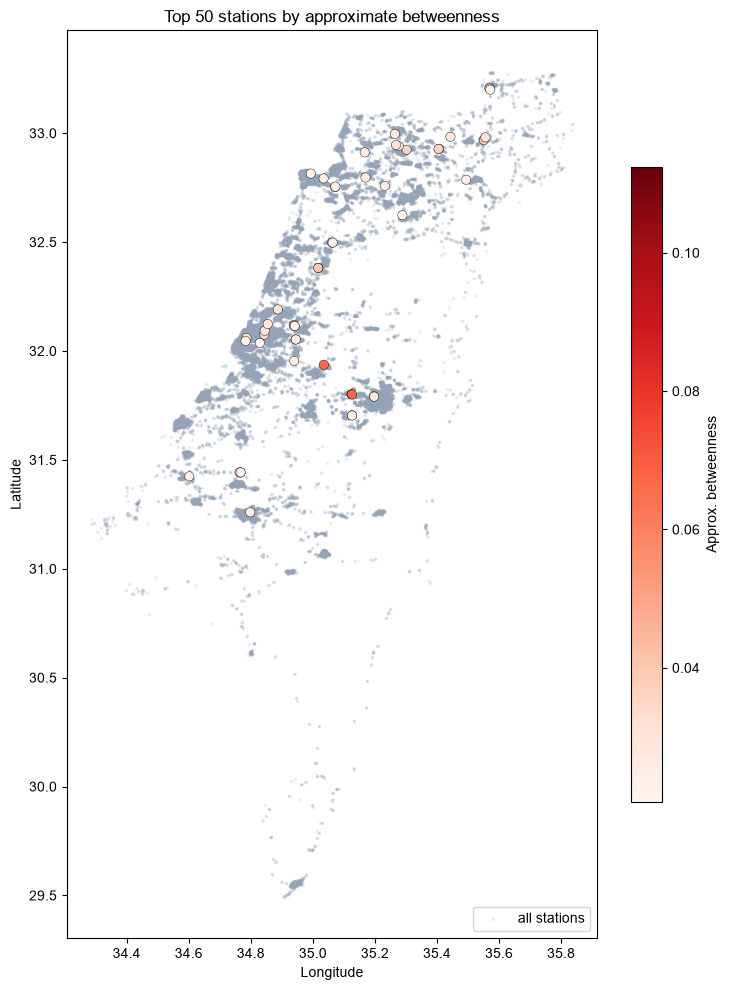

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(metrics["degree"], metrics["approx_betweenness"],
                s=4, alpha=0.3, color="#2563eb")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Approx. betweenness")
axes[0].set_title("Degree vs betweenness (disagreement is the interesting part)")
axes[1].scatter(metrics["degree"], metrics["pagerank"],
                s=4, alpha=0.3, color="#16a34a")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("PageRank")
axes[1].set_yscale("log")
axes[1].set_title("Degree vs PageRank (log scale)")
fig.tight_layout()
fig.savefig(FIGURES / "centrality_scatter.png", dpi=150)
plt.show()

geo = metrics.dropna(subset=["lat", "lon"]).copy()
if len(geo):
    top_geo = geo.nlargest(50, "approx_betweenness")
    fig, ax = plt.subplots(figsize=(7.5, 10))
    ax.scatter(geo["lon"], geo["lat"], s=2, alpha=0.15, color="#94a3b8", label="all stations")
    sc = ax.scatter(top_geo["lon"], top_geo["lat"], s=45,
                    c=top_geo["approx_betweenness"], cmap="Reds",
                    edgecolors="black", linewidths=0.3, zorder=5)
    fig.colorbar(sc, ax=ax, label="Approx. betweenness", shrink=0.7)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Top 50 stations by approximate betweenness")
    ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(FIGURES / "betweenness_map.png", dpi=150)
    plt.show()
else:
    print("No coordinates available in the stage-02 node table - skipping the map.")

## 15. Checking weighted degree against station visits

We use station visit counts only as a graph-construction check. A very high correlation with weighted degree is expected from the definitions and is not independent evidence about station importance.

Both quantities come from the same stop-time rows. An interior visit to station `s` contributes one incoming and one outgoing segment, so

```
weighted_degree(s) = in_weight(s) + out_weight(s) ~= 2 * visits(s)
```

Trip endpoints contribute only one side, and consecutive duplicate stops are dropped during graph construction, which explains deviations from the approximate factor of two.

The cell first verifies the exact identity `weighted_degree == in_weight + out_weight`. It then uses an existing visit-count artifact if available, or streams local `stop_times.txt` if the file is already on disk. We do not download the large file just for this. The resulting correlation and fitted slope tell us whether edge-frequency aggregation is consistent with visit totals; they do not add a new centrality finding.

In [15]:
# 1) Exact identity: undirected weighted degree = in_weight + out_weight.
identity_gap = (metrics["weighted_degree"]
                - (metrics["in_weight"] + metrics["out_weight"])).abs().max()
print(f"max |weighted_degree - (in_weight + out_weight)| = {identity_gap:.6f} "
      "(0 means the two are the same quantity)")

# 2) Visit counts, only if they are already available - no 816 MB download here.
visits = metrics["stop_use_count"]
if visits.notna().sum() == 0:
    stop_times_path = DATA / "stop_times.txt"
    if stop_times_path.exists():
        print("Counting stop visits from the local stop_times.txt (one streaming pass) ...")
        csv.field_size_limit(10_000_000)
        counts = Counter()
        with open(stop_times_path, encoding="utf-8-sig") as handle:
            reader = csv.reader(handle)
            header = next(reader)
            si = header.index("stop_id")
            for row in reader:
                counts[row[si]] += 1
        visits = metrics["stop_id"].map(counts)
    else:
        visits = pd.Series(np.nan, index=metrics.index)

if visits.notna().sum() > 0:
    paired = pd.DataFrame({"weighted_degree": metrics["weighted_degree"].astype(float),
                           "visits": visits.astype(float)}).dropna()
    rho = paired["weighted_degree"].corr(paired["visits"], method="spearman")
    ratio = (paired["weighted_degree"] / paired["visits"].replace(0, np.nan)).median()
    print(f"Spearman(weighted_degree, visits) = {rho:.4f} over {len(paired):,} stations")
    print(f"median weighted_degree / visits   = {ratio:.3f}  (~2 confirms the identity above)")
    print("Reminder: this is a definitional relationship, not an empirical finding.")
else:
    print("No visit-count column from stage 02 and no local stop_times.txt - "
          "skipping the numeric check. The identity in the markdown above still holds.")

max |weighted_degree - (in_weight + out_weight)| = 0.000000 (0 means the two are the same quantity)
Spearman(weighted_degree, visits) = 0.9943 over 30,463 stations
median weighted_degree / visits   = 2.000  (~2 confirms the identity above)
Reminder: this is a definitional relationship, not an empirical finding.


## 16. Conclusions

The rankings answer different questions and are not interchangeable. In this run, weighted degree has Spearman correlation `0.6084` with PageRank and `0.4681` with degree. Approximate betweenness correlates `0.5139` with degree but only `0.1868` with weighted degree and `0.3220` with PageRank. The low-degree, high-betweenness outliers are therefore not just the busiest stops under another name; local service volume alone misses some structural connectors.

The precision of that betweenness ranking is limited by the 300-source sample, about 0.99% of the 30,237-node LCC. The second seed gives overall Spearman `0.9564`, 90% top-10 overlap, and 84% top-50 overlap, but the two p90 sets have Jaccard overlap only `0.5296`. We therefore treat stations near a betweenness cutoff as uncertain rather than turning one sampled percentile into a perfectly sharp category. Increasing `K_BETWEENNESS` should reduce sampling variation at roughly linear computational cost; exact calculation would remove source-sampling error but is much more expensive.

Harmonic centrality adds a third interpretation. It rewards short distance to the rest of the LCC, so dense central geography tends to score well even when a station is not the main bridge between regions. Its sampled estimate averages many reciprocal distances and is generally smoother than betweenness, though it is still an approximation under the current settings.

The visit-count check behaves as expected from construction: weighted degree is exactly incoming plus outgoing weight and is approximately twice station visits away from trip endpoints and duplicate-stop exceptions. A correlation near 0.99 here validates aggregation consistency; it does not show a new relationship between traffic and centrality.

Finally, the global path metrics cover the largest connected component rather than all components jointly. Nodes outside it receive zero and are marked by `in_largest_component`, so we can distinguish a structural outside-LCC zero from a very small within-LCC estimate. The saved metrics and stability table carry both the ranking information and the caveats needed for selecting critical stations in the next step.